# Trabajo de ampliación (1 punto): PneumoniaMNIST (Keras/TFDS)

Este cuaderno **ya incluye**: carga de datos + preprocesado, entrenamiento y evaluación del **modelo base (Parte 0)**.

Tu trabajo consiste en completar:

- **Parte 1**: una mejora del modelo base usando **exactamente 2** técnicas (de la lista dada).
- **Parte 2**: **Transfer Learning** con **MobileNetV2** preentrenada (2A congelado y 2B fine-tuning parcial).

**Restricciones (obligatorias)**  
- No modificar las particiones de entrenamento y validación, ni usar datos externos.  
- Máximo **20 épocas** por entrenamiento.  
- Máximo **3 ejecuciones** por parte (para ajuste).  
- Mantener la misma semilla.  
- Métricas obligatorias en **test**: Accuracy, F1 y matriz de confusión.  
- Informe final: **≤ 3 páginas** (fuera de este cuaderno).

> Nota: Este dataset es un benchmark educativo; **no** debe interpretarse como un sistema clínico.


In [1]:
# =========================
# 0) Imports y configuración
# =========================
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense,
    Activation,
    MaxPooling2D,
    RandomFlip,
    RandomRotation,
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

# Semilla fija (NO modificar)
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Para reproducibilidad adicional (mejor esfuerzo; GPU puede seguir siendo no determinista)
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE


TensorFlow: 2.19.0


## 1) Carga del dataset con [TFDS](https://www.tensorflow.org/datasets/api_docs/python/tfds)

Usamos `pneumonia_mnist` desde [TFDS](https://www.tensorflow.org/datasets/api_docs/python/tfds) en los splits estándar: `train`, `val`, `test`.


In [2]:
# =========================
# 1) Carga de datos (TFDS)
# =========================
(ds_train, ds_val, ds_test), info = tfds.load(
    "pneumonia_mnist",
    split=["train", "val", "test"],
    as_supervised=True,
    with_info=True
)

print(info)

tfds.core.DatasetInfo(
    name='pneumonia_mnist',
    full_name='pneumonia_mnist/1.0.0',
    description="""
    # MedMNIST Pneumonia Dataset
    
    The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray
    images. The task is binary-class classification of pneumonia against normal. The
    source training set is split with a ratio of 9:1 into training and validation
    set, and use its source validation set as the test set. The source images are
    gray-scale, and their sizes are (384–2,916) × (127–2,713). The images are
    center-cropped with a window size of length of the short edge and resized into 1
    × 28 × 28.
    """,
    homepage='https://medmnist.com//',
    data_dir='/root/tensorflow_datasets/pneumonia_mnist/1.0.0',
    file_format=tfrecord,
    download_size=3.98 MiB,
    dataset_size=3.66 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),

In [3]:
# =================================
# 2) Preprocesado (28x28x1)
# =================================
BATCH_BASE = 64

def prep(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.reshape(x, [28, 28, 1])
    y = tf.cast(y, tf.float32)
    return x, y

train = (ds_train
            .shuffle(2000, seed=SEED, reshuffle_each_iteration=True)
            .map(prep, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_BASE)
            .prefetch(AUTOTUNE))

val   = (ds_val
          .map(prep, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_BASE)
          .prefetch(AUTOTUNE))

test  = (ds_test
           .map(prep, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_BASE)
           .prefetch(AUTOTUNE))


### Visualización rápida

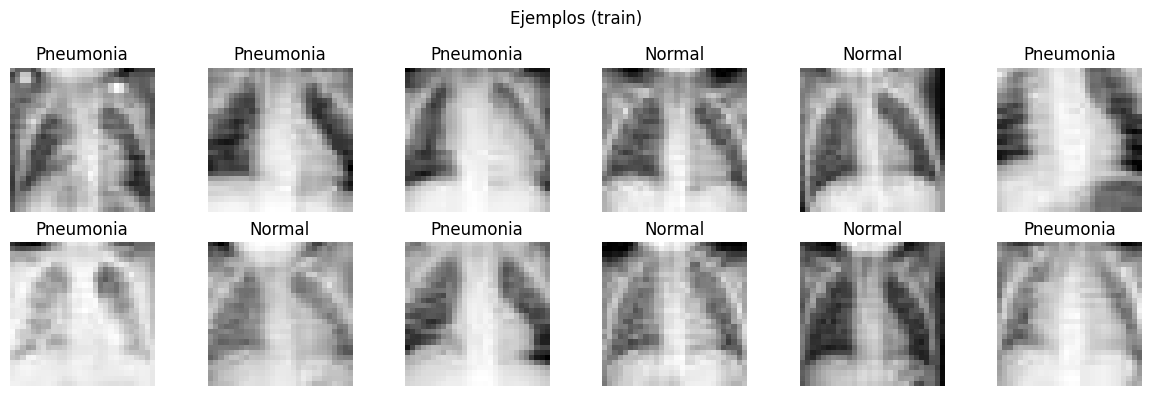

In [4]:
def show_batch(ds, n=12, title="Batch"):
    xs, ys = next(iter(ds))
    xs = xs.numpy()
    ys = ys.numpy().astype(int)
    n = min(n, xs.shape[0])
    cols = 6
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*2, rows*2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(xs[i].squeeze(), cmap="gray")
        plt.title("Pneumonia" if ys[i] == 1 else "Normal")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_batch(train, title="Ejemplos (train)")


## 3) Utilidades: métricas, evaluación y gráficas

- Se calcularán en **test**: Accuracy, F1 y matriz de confusión.
- Además, se calculará un *gap* simple: `train_acc_last - val_acc_last`.


In [5]:
def plot_history(history, title="Training curves"):
    h = history.history
    plt.figure(figsize=(6,4))
    plt.plot(h.get("loss", []), label="train_loss")
    plt.plot(h.get("val_loss", []), label="val_loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # accuracy metric name may vary; default we use 'acc'
    acc_key = "acc" if "acc" in h else ("binary_accuracy" if "binary_accuracy" in h else None)
    val_acc_key = "val_" + acc_key if acc_key and ("val_" + acc_key) in h else None

    if acc_key and val_acc_key:
        plt.figure(figsize=(6,4))
        plt.plot(h[acc_key], label="train_acc")
        plt.plot(h[val_acc_key], label="val_acc")
        plt.title(title + " - Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()
    else:
        print("No se encontró métrica de accuracy en history.")

def compute_metrics_on_test(model, test_ds, threshold=0.5):
    y_true = []
    y_prob = []
    for xb, yb in test_ds:
        pb = model.predict(xb, verbose=0).reshape(-1)
        y_true.append(yb.numpy().reshape(-1))
        y_prob.append(pb)
    y_true = np.concatenate(y_true).astype(int)
    y_prob = np.concatenate(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    # Accuracy
    acc = (y_pred == y_true).mean()

    # F1 (binary)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    # Confusion matrix: [[tn, fp],[fn,tp]]
    tn = np.sum((y_pred == 0) & (y_true == 0))
    cm = np.array([[tn, fp],
                   [fn, tp]], dtype=int)

    return {
        "test_acc": float(acc),
        "test_f1": float(f1),
        "cm": cm,
        "precision": float(precision),
        "recall": float(recall),
    }

def last_gap_from_history(history):
    h = history.history
    acc_key = "acc" if "acc" in h else ("binary_accuracy" if "binary_accuracy" in h else None)
    if not acc_key:
        return None
    val_key = "val_" + acc_key
    if val_key not in h:
        return None
    return float(h[acc_key][-1] - h[val_key][-1])

def print_cm(cm):
    print("Confusion matrix [[TN, FP],[FN, TP]]:")
    print(cm)


## 4) Parte 0 — Modelo base (YA HECHO)

Arquitectura: CNN pequeña-mediana sin regularización explícita, pensada para que aparezca algo de gap train–val.

Entrenamiento: Adam LR=1e-3, batch=64, **20 épocas**.


In [6]:
# =========================
# 4) Parte 0: modelo base
# =========================
def make_base_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPool2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    return model

base_model = make_base_model()
base_model.compile(
    optimizer=Adam(1e-3),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="acc")]
)
base_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,129 (672.38 KB)

 Trainable params: 172,129 (672.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - acc: 0.7420 - loss: 0.5919 - val_acc: 0.7424 - val_loss: 0.5013
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8360 - loss: 0.3369 - val_acc: 0.9256 - val_loss: 0.1819
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9261 - loss: 0.1937 - val_acc: 0.9504 - val_loss: 0.1540
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9274 - loss: 0.1627 - val_acc: 0.9427 - val_loss: 0.1419
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9430 - loss: 0.1470 - val_acc: 0.9237 - val_loss: 0.1709
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9414 - loss: 0.1448 - val_acc: 0.9237 - val_loss: 0.1656
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9464 - loss: 0.1249 - val_acc: 0.9485 - val_loss: 0.1379
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9581 - loss: 0.1083 - val_acc: 0.9542 - val_loss: 0.1100
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9571 - loss:

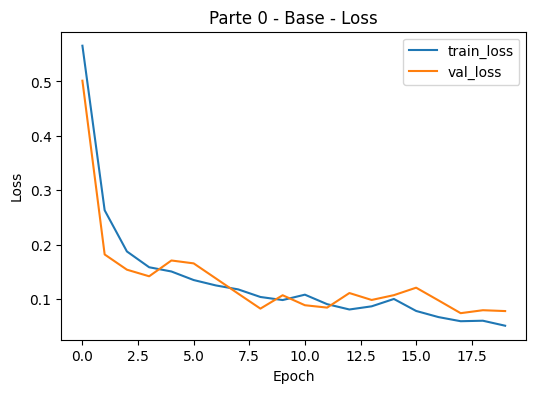

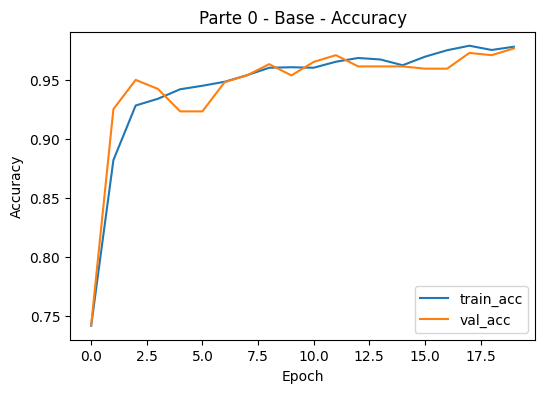

Gap (train_acc_last - val_acc_last): 0.001447916030883789
Test acc: 0.8766025641025641 Test F1: 0.9088757391457778
Confusion matrix [[TN, FP],[FN, TP]]:
[[163  71]
 [  6 384]]


In [7]:
# Entrenamiento Parte 0
history_base = base_model.fit(
    train,
    validation_data=val,
    epochs=20,
    verbose=1
)
plot_history(history_base, title="Parte 0 - Base")
gap_base = last_gap_from_history(history_base)
metrics_base = compute_metrics_on_test(base_model, test)
print("Gap (train_acc_last - val_acc_last):", gap_base)
print("Test acc:", metrics_base["test_acc"], "Test F1:", metrics_base["test_f1"])
print_cm(metrics_base["cm"])


## 5) Tabla de resultados (se irá rellenando)

Esta tabla se usará al final para el informe (Base vs Parte 1 vs Parte 2A vs Parte 2B).


In [ ]:
results = []

def add_result(results, name, techniques, history, test_metrics):
    gap = last_gap_from_history(history) if history is not None else None
    results.append({
        "Modelo": name,
        "Técnicas": techniques,
        "Test Acc": test_metrics.get("test_acc"),
        "Test F1": test_metrics.get("test_f1"),
        "Gap Train–Val (Acc)": gap
    })

# Añadimos la Parte 0
add_result(results, "Base (Parte 0)", "—", history_base, metrics_base)

def results_table(results):
    df = pd.DataFrame(results)
    return df

results_table(results)


,Modelo,Técnicas,Test Acc,Test F1,Gap Train–Val (Acc)
0,Base (Parte 0),—,0.876603,0.908876,0.001448


# ✅ Tu trabajo empieza aquí

---

## Parte 1 — Mejora combinada (exactamente 2 técnicas)

Elige **exactamente 2** técnicas de esta lista:

1) Dropout  
2) Regularización L1 o L2
3) Normalización por lotes  
4) Data augmentation (ligera)
5) Early stopping  

**Reglas**:
- No cambiar el “esqueleto” (mismos bloques conv y densas).  
- Máx. 20 épocas.  
- Máx. 3 ejecuciones para ajuste.

### Qué debes hacer
1) Implementa `make_model_part1()` añadiendo **exactamente 2** técnicas.  
2) Define callbacks si aplican (por ejemplo, early stopping).  
3) Entrena, genera gráficas, evalúa en test, añade a `results`.


In [ ]:
PART1_TECHNIQUES = "None" # TODO: escribe explícitamente las dos técnicas en esta variable

In [ ]:
# =========================
# 5) Parte 1
# =========================

def make_model_part1():
    """TODO: crea el modelo de Parte 1.
    Mantén el mismo esqueleto que el modelo base, pero añade EXACTAMENTE 2 técnicas.
    """
    # model = ...

    return model


In [ ]:
# Entrena Parte 1 (ejecuta cuando completes los TODOs de esta parte)
part1_model = make_model_part1()

part1_model.compile(
    optimizer=Adam(1e-3),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="acc")]
)

history_part1 = part1_model.fit(
    train,
    validation_data=val,
    # TODO: callbacks=[],
    epochs=20
)

plot_history(history_part1, title="Parte 1")
metrics_part1 = compute_metrics_on_test(part1_model, test)
print("Test acc:", metrics_part1["test_acc"], "Test F1:", metrics_part1["test_f1"])
print_cm(metrics_part1["cm"])

add_result(results, "Mejorado (Parte 1)", PART1_TECHNIQUES, history_part1, metrics_part1)
results_table(results)


---

## Parte 2 — Transfer Learning con MobileNetV2

Se trabajará con imágenes reescaladas a **96×96×3** y `preprocess_input` de MobileNetV2.

Debes entrenar:
- **2A**: MobileNetV2 congelada (*feature extractor*)
- **2B**: fine-tuning parcial (descongelar ~últimas 20 capas)

> Consejo: para 2B usa LR=1e-5 y *EarlyStopping*.


In [ ]:
# ==========================================
# 6) Preprocesado MobileNetV2: 96x96x3 (Parte 2)
# ==========================================

IMG_TL = 96
BATCH_TL = 64

def prep_mnv2(x, y):
    x = tf.cast(x, tf.float32)  # keep [0..255] for preprocess_input
    x = tf.reshape(x, [28, 28, 1])
    x = tf.image.resize(x, [IMG_TL, IMG_TL], method="bilinear")
    x = tf.tile(x, [1, 1, 3])  # 1 canal -> 3 canales
    x = preprocess_input(x)    # expects float image in [0..255] range-ish
    y = tf.cast(y, tf.float32)
    return x, y


train_mnv2 = (ds_train
              .shuffle(2000, seed=SEED, reshuffle_each_iteration=True)
              .map(prep_mnv2, num_parallel_calls=AUTOTUNE)
              .batch(BATCH_TL)
              .prefetch(AUTOTUNE))

val_mnv2 = (ds_val
            .map(prep_mnv2, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_TL)
            .prefetch(AUTOTUNE))


test_mnv2 = (ds_test
            .map(prep_mnv2, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_TL)
            .prefetch(AUTOTUNE))

In [ ]:
# =========================
# 7) Parte 2A: MobileNetV2 congelada
# =========================

# Cargar base pre-entrenada sin la parte de clasificación
base_mnv2_2a = MobileNetV2(
    input_shape=(IMG_TL, IMG_TL, 3),
    include_top=False,
    weights="imagenet",
)

# Congelar todas las capas del modelo base
for layer in base_mnv2_2a.layers:
    layer.trainable = False

# Añadir cabeza densa específica para este problema de clasificación
model_2a = Sequential([
    base_mnv2_2a,
    Flatten(),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_2a.compile(
    optimizer=Adam(1e-3),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="acc")],
)

history_2a = model_2a.fit(
    train_mnv2,
    validation_data=val_mnv2,
    epochs=20,
    verbose=1,
)

plot_history(history_2a, title="Parte 2A - MobileNetV2 Frozen")
metrics_2a = compute_metrics_on_test(model_2a, test_mnv2)
print("Test acc:", metrics_2a["test_acc"], "Test F1:", metrics_2a["test_f1"])
print_cm(metrics_2a["cm"])

add_result(results, "TL congelado (2A)", "MobileNetV2 frozen", history_2a, metrics_2a)
results_table(results)


In [ ]:
# =========================
# 8) Parte 2B: Fine-tuning parcial
# =========================

# Recomendación: descongelar a partir de una capa intermedia
UNFREEZE_FROM_LAYER_NAME = "block_15_project_BN"  # TODO: Ajustar este nombre

base_mnv2_2b = MobileNetV2(
    input_shape=(IMG_TL, IMG_TL, 3),
    include_top=False,
    weights="imagenet",
)

# Descongelar parcialmente a partir de UNFREEZE_FROM_LAYER_NAME
set_trainable = False
for layer in base_mnv2_2b.layers:
    if layer.name == UNFREEZE_FROM_LAYER_NAME:
        set_trainable = True
    layer.trainable = set_trainable

model_2b = Sequential([
    base_mnv2_2b,
    Flatten(),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid"),
])

# LR pequeño para fine-tuning
model_2b.compile(
    optimizer=Adam(1e-5),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="acc")],
)

history_2b = model_2b.fit(
    train_mnv2 ,
    validation_data=val_mnv2,
    epochs=20,
    callbacks=EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    verbose=1,
)

plot_history(history_2b, title="Parte 2B - MobileNetV2 Fine-tuning")
metrics_2b = compute_metrics_on_test(model_2b, test_mnv2)
print("Test acc:", metrics_2b["test_acc"], "Test F1:", metrics_2b["test_f1"])
print_cm(metrics_2b["cm"])

add_result(
    results,
    "TL fine-tuning (2B)",
    f"MobileNetV2, unfreeze from {UNFREEZE_FROM_LAYER_NAME}",
    history_2b,
    metrics_2b,
)
results_table(results)


## 9) Resumen final

- Asegúrate de que la tabla incluye las 4 filas: Base, Parte 1, 2A, 2B.

In [ ]:
df = results_table(results)
df